<a href="https://colab.research.google.com/github/sabrynkhatr696-design/Machine-Learning-Projects/blob/main/Project_LSTM_Time_Series_Forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 📌 Project Title

Time Series Forecasting using LSTM Neural Network

### 📖 Description

This notebook implements a deep learning model using LSTM (Long Short-Term Memory) to predict values in a time series dataset.
A synthetic sine wave is generated and transformed into sequences using a sliding window approach for supervised learning.

The goal is to demonstrate how recurrent neural networks can learn temporal dependencies and make accurate predictions

### 🧠 Model Used
LSTM Neural Network
Dense Layers
Dropout Regularization

### 1️⃣ استيراد المكتبات + إنشاء بيانات (sin wave)

In [21]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# إنشاء بيانات رياضية
x = np.linspace(0, 50, 1000)
y = np.sin(x)

### 2️⃣ تحويل البيانات إلى sequences

In [22]:
def create_dataset(data, time_steps=20):
    X, Y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        Y.append(data[i+time_steps])

    X = np.array(X)
    Y = np.array(Y)

    # تحويل الشكل ليكون مناسب لـ LSTM (3D)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    return X, Y


time_steps = 20
X, Y = create_dataset(y, time_steps)

# تقسيم البيانات
split = int(0.8 * len(X))
x_train, x_test = X[:split], X[split:]
y_train, y_test = Y[:split], Y[split:]

### 3️⃣ بناء النموذج (LSTM)

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import Input

model = Sequential([
    Input(shape=(time_steps, 1)),   # حل التحذير
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse',   # regression
    metrics=['mae']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

### 4️⃣ تدريب النموذج

In [24]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    x_train, y_train,
    epochs=50,                # رفعناها، و EarlyStopping بوقف بدري
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.2395 - mae: 0.4171 - val_loss: 0.0524 - val_mae: 0.2007
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0503 - mae: 0.2001 - val_loss: 0.0181 - val_mae: 0.1181
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0152 - mae: 0.1016 - val_loss: 0.0056 - val_mae: 0.0626
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0082 - mae: 0.0698 - val_loss: 0.0027 - val_mae: 0.0386
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0062 - mae: 0.0606 - val_loss: 0.0015 - val_mae: 0.0324
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0052 - mae: 0.0564 - val_loss: 7.4945e-04 - val_mae: 0.0229
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0048 - mae: 0.0539 - val_loss: 0.0010 - val_mae: 0.0262
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0047 - mae: 0.0523 - val_loss: 4.6674e-04 - val_mae: 0.0183
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - los

###5️⃣ التقييم

In [25]:
loss, mae = model.evaluate(x_test, y_test)
print("Loss:", loss)
print("MAE:", mae)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.0057e-04 - mae: 0.0122 
Loss: 0.00020056607900187373
MAE: 0.012227392755448818


### 6️⃣ التوقع والرسم 📈

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


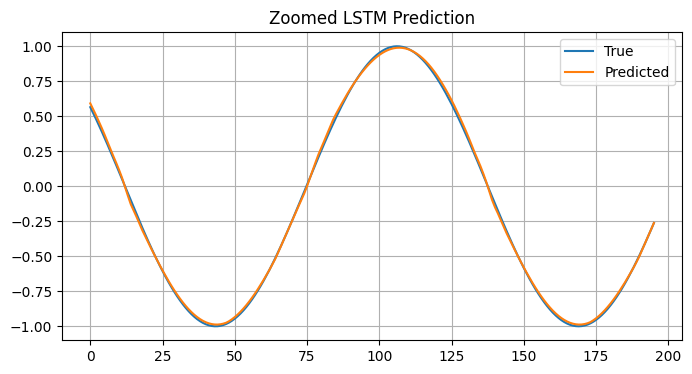

In [28]:
import matplotlib.pyplot as plt

predictions = model.predict(x_test)

# تحويل الشكل إلى 1D
predictions = predictions.reshape(-1)
y_test = y_test.reshape(-1)

# الرسم (Zoomed View)
plt.figure(figsize=(8, 4))
plt.plot(y_test[:200], label="True")
plt.plot(predictions[:200], label="Predicted")
plt.legend()
plt.grid(True)
plt.title("Zoomed LSTM Prediction")
plt.show()

### 📊 Results
* MAE: ~0.012
* Loss: ~0.00020
* High accuracy in sequence prediction
* Good generalization with no significant overfitting

### 📌 Notes
This is a basic time series forecasting project using synthetic data
Can be extended to real-world datasets like stocks, crypto, or sensor data

### 🔥 Author

Sabrin Kater